In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense,LSTM, Dropout,Input, Concatenate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta



# Este dataframe contiene los precios historicos del boleto desde el año 1994 hasta el año 2019. 

**Carga y Visualizacion de los Datos**

- E siguiente código carga el dataset “registro-historico-del-precio-del-boleto.csv” y muestra las primeras 10 filas para una revisión inicial de su contenido.
- Esto nos permite inspeccionar la estructura del archivo, identificar las columnas disponibles y verificar que los datos se hayan importado correctamente antes de aplicar transformaciones o análisis posteriores.

In [3]:
#Cargamos el dataset y mostramos los primeros 10 registros.
df=pd.read_csv("registro-historico-del-precio-del-boleto.csv")
df.head(10)


,año,mes_numero,mes,precio
0,1994,1,ENERO,0.45
1,1994,2,FEBRERO,0.45
2,1994,3,MARZO,0.45
3,1994,4,ABRIL,0.45
4,1994,5,MAYO,0.45
5,1994,6,JUNIO,0.45
6,1994,7,JULIO,0.45
7,1994,8,AGOSTO,0.45
8,1994,9,SEPTIEMBRE,0.45
9,1994,10,OCTUBRE,0.45


**EXPLORACION del DATAFRAME**

- En el siguiente bloque de código, realizo una exploración inicial del dataset para evaluar su estructura, calidad y contenido.
- A continuación, se detallan las funciones utilizadas:
- •	df.info(): muestra el número de entradas, columnas, tipos de datos y valores no nulos por columna.
- •	df.isnull().sum(): indica la cantidad de valores nulos por columna.
- •	print(df.isna().sum().sum()): muestra el total de valores nulos en todo el dataset.
- •	df.duplicated().sum(): cuenta la cantidad de filas duplicadas.
- •	df.dtypes: informa los tipos de datos de cada columna.
- •	df.columns: lista los nombres de todas las columnas.
- •	df.sample(5): extrae 5 filas aleatorias para revisar ejemplos de datos.
- •	df.describe(): genera estadísticas descriptivas para las columnas numéricas.

- En conjunto, este análisis nos permite conocer el estado general del dataset antes de su limpieza o análisis más profundo.

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   año         304 non-null    int64  
 1   mes_numero  304 non-null    int64  
 2   mes         304 non-null    object 
 3   precio      304 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 9.6+ KB


In [5]:
df.isnull().sum()

año           0
mes_numero    0
mes           0
precio        0
dtype: int64

In [6]:
print(df.isna().sum().sum())

0


In [7]:
df.duplicated().sum()

0

In [8]:
df.dtypes



año             int64
mes_numero      int64
mes            object
precio        float64
dtype: object

In [9]:
df.columns


Index(['año', 'mes_numero', 'mes', 'precio'], dtype='object')

In [10]:
df.sample(5)



,año,mes_numero,mes,precio
115,2003,8,AGOSTO,0.7
214,2011,11,NOVIEMBRE,1.1
89,2001,6,JUNIO,0.7
139,2005,8,AGOSTO,0.7
291,2018,4,ABRIL,7.5


df.shape



In [11]:
df.describe()


,año,mes_numero,precio
count,304.000000,304.000000,304.000000
mean,2006.171053,6.447368,2.154112
std,7.327129,3.467510,3.000518
min,1994.000000,1.000000,0.450000
25%,2000.000000,3.000000,0.600000
50%,2006.000000,6.000000,0.700000
75%,2012.250000,9.000000,2.500000
max,2019.000000,12.000000,19.000000


**Visualizacion Grafica de datos**

In [12]:
import matplotlib.pyplot as plt

- El siguiente bloque de código tiene como objetivo organizar y visualizar la evolución del precio del boleto de subte en Argentina entre 1994 y 2019, tanto de forma anual como mensual. 

- A continuación, se explica cada paso:
	1.	Tabla organizada por año y mes:
- •	Se crea una tabla (lineapass) con los precios mensuales del boleto por año.
- •	Se asegura el orden cronológico de los meses.
- •	Se rellenan valores faltantes con 19 como valor por defecto.

	2.	Gráfico de línea anual (1994–2019):
- •	Se representa visualmente la evolución del precio promedio anual del boleto, lo que permite identificar tendencias generales, incrementos y períodos de estabilidad.

	3.	Gráficos de barras mensuales por año:
- •	Se genera una serie de subgráficos (uno por año) que muestran el precio del boleto mes a mes, permitiendo un análisis más detallado de los cambios dentro de cada año.

- Estas visualizaciones en conjunto permiten obtener una comprensión clara de cómo fue variando el precio del boleto tanto en el largo plazo como dentro de cada año.

Total de viajes por LINEA por AÑO.
mes   ENERO  FEBRERO  MARZO  ABRIL   MAYO  JUNIO  JULIO  AGOSTO  SEPTIEMBRE  OCTUBRE  NOVIEMBRE  DICIEMBRE
año                                                                                                       
1994   0.45     0.45   0.45   0.45   0.45   0.45   0.45    0.45        0.45     0.45       0.45       0.45
1995   0.45     0.45   0.45   0.45   0.45   0.45   0.45    0.45        0.45     0.45       0.45       0.45
1996   0.45     0.45   0.45   0.45   0.45   0.45   0.45    0.45        0.45     0.50       0.50       0.50
1997   0.50     0.50   0.50   0.50   0.50   0.50   0.50    0.50        0.50     0.50       0.50       0.50
1998   0.50     0.50   0.50   0.50   0.50   0.50   0.50    0.50        0.50     0.50       0.50       0.50
1999   0.50     0.50   0.50   0.50   0.60   0.60   0.60    0.60        0.60     0.60       0.60       0.60
2000   0.60     0.60   0.60   0.60   0.60   0.60   0.60    0.60        0.60     0.60       0.60       0.60
20

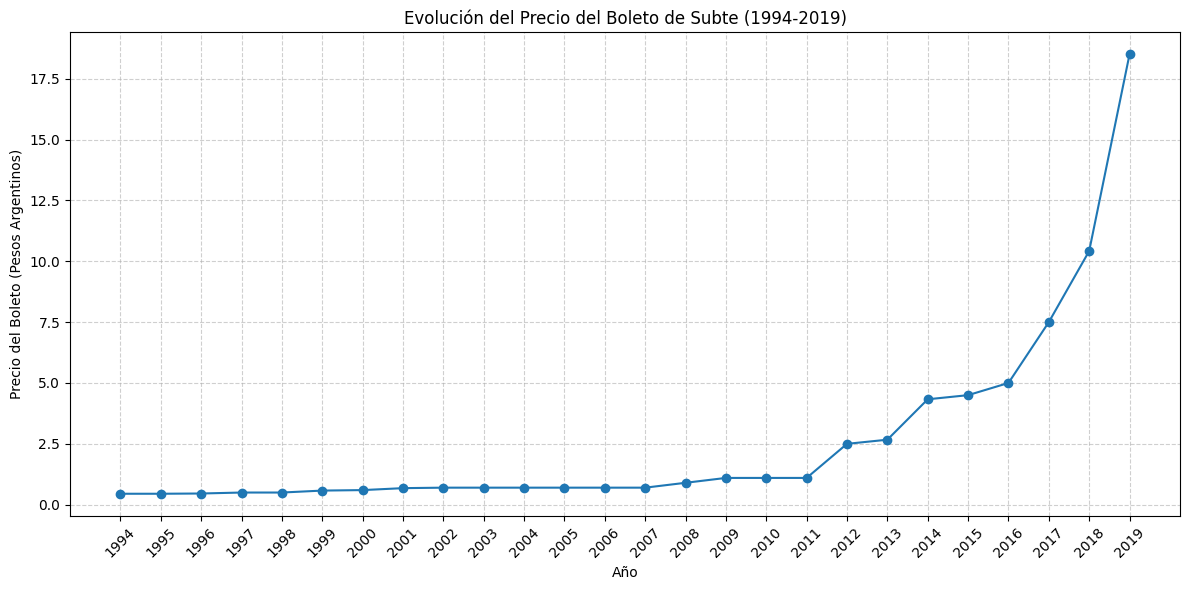

Evolucion Precio Boleto Mensual


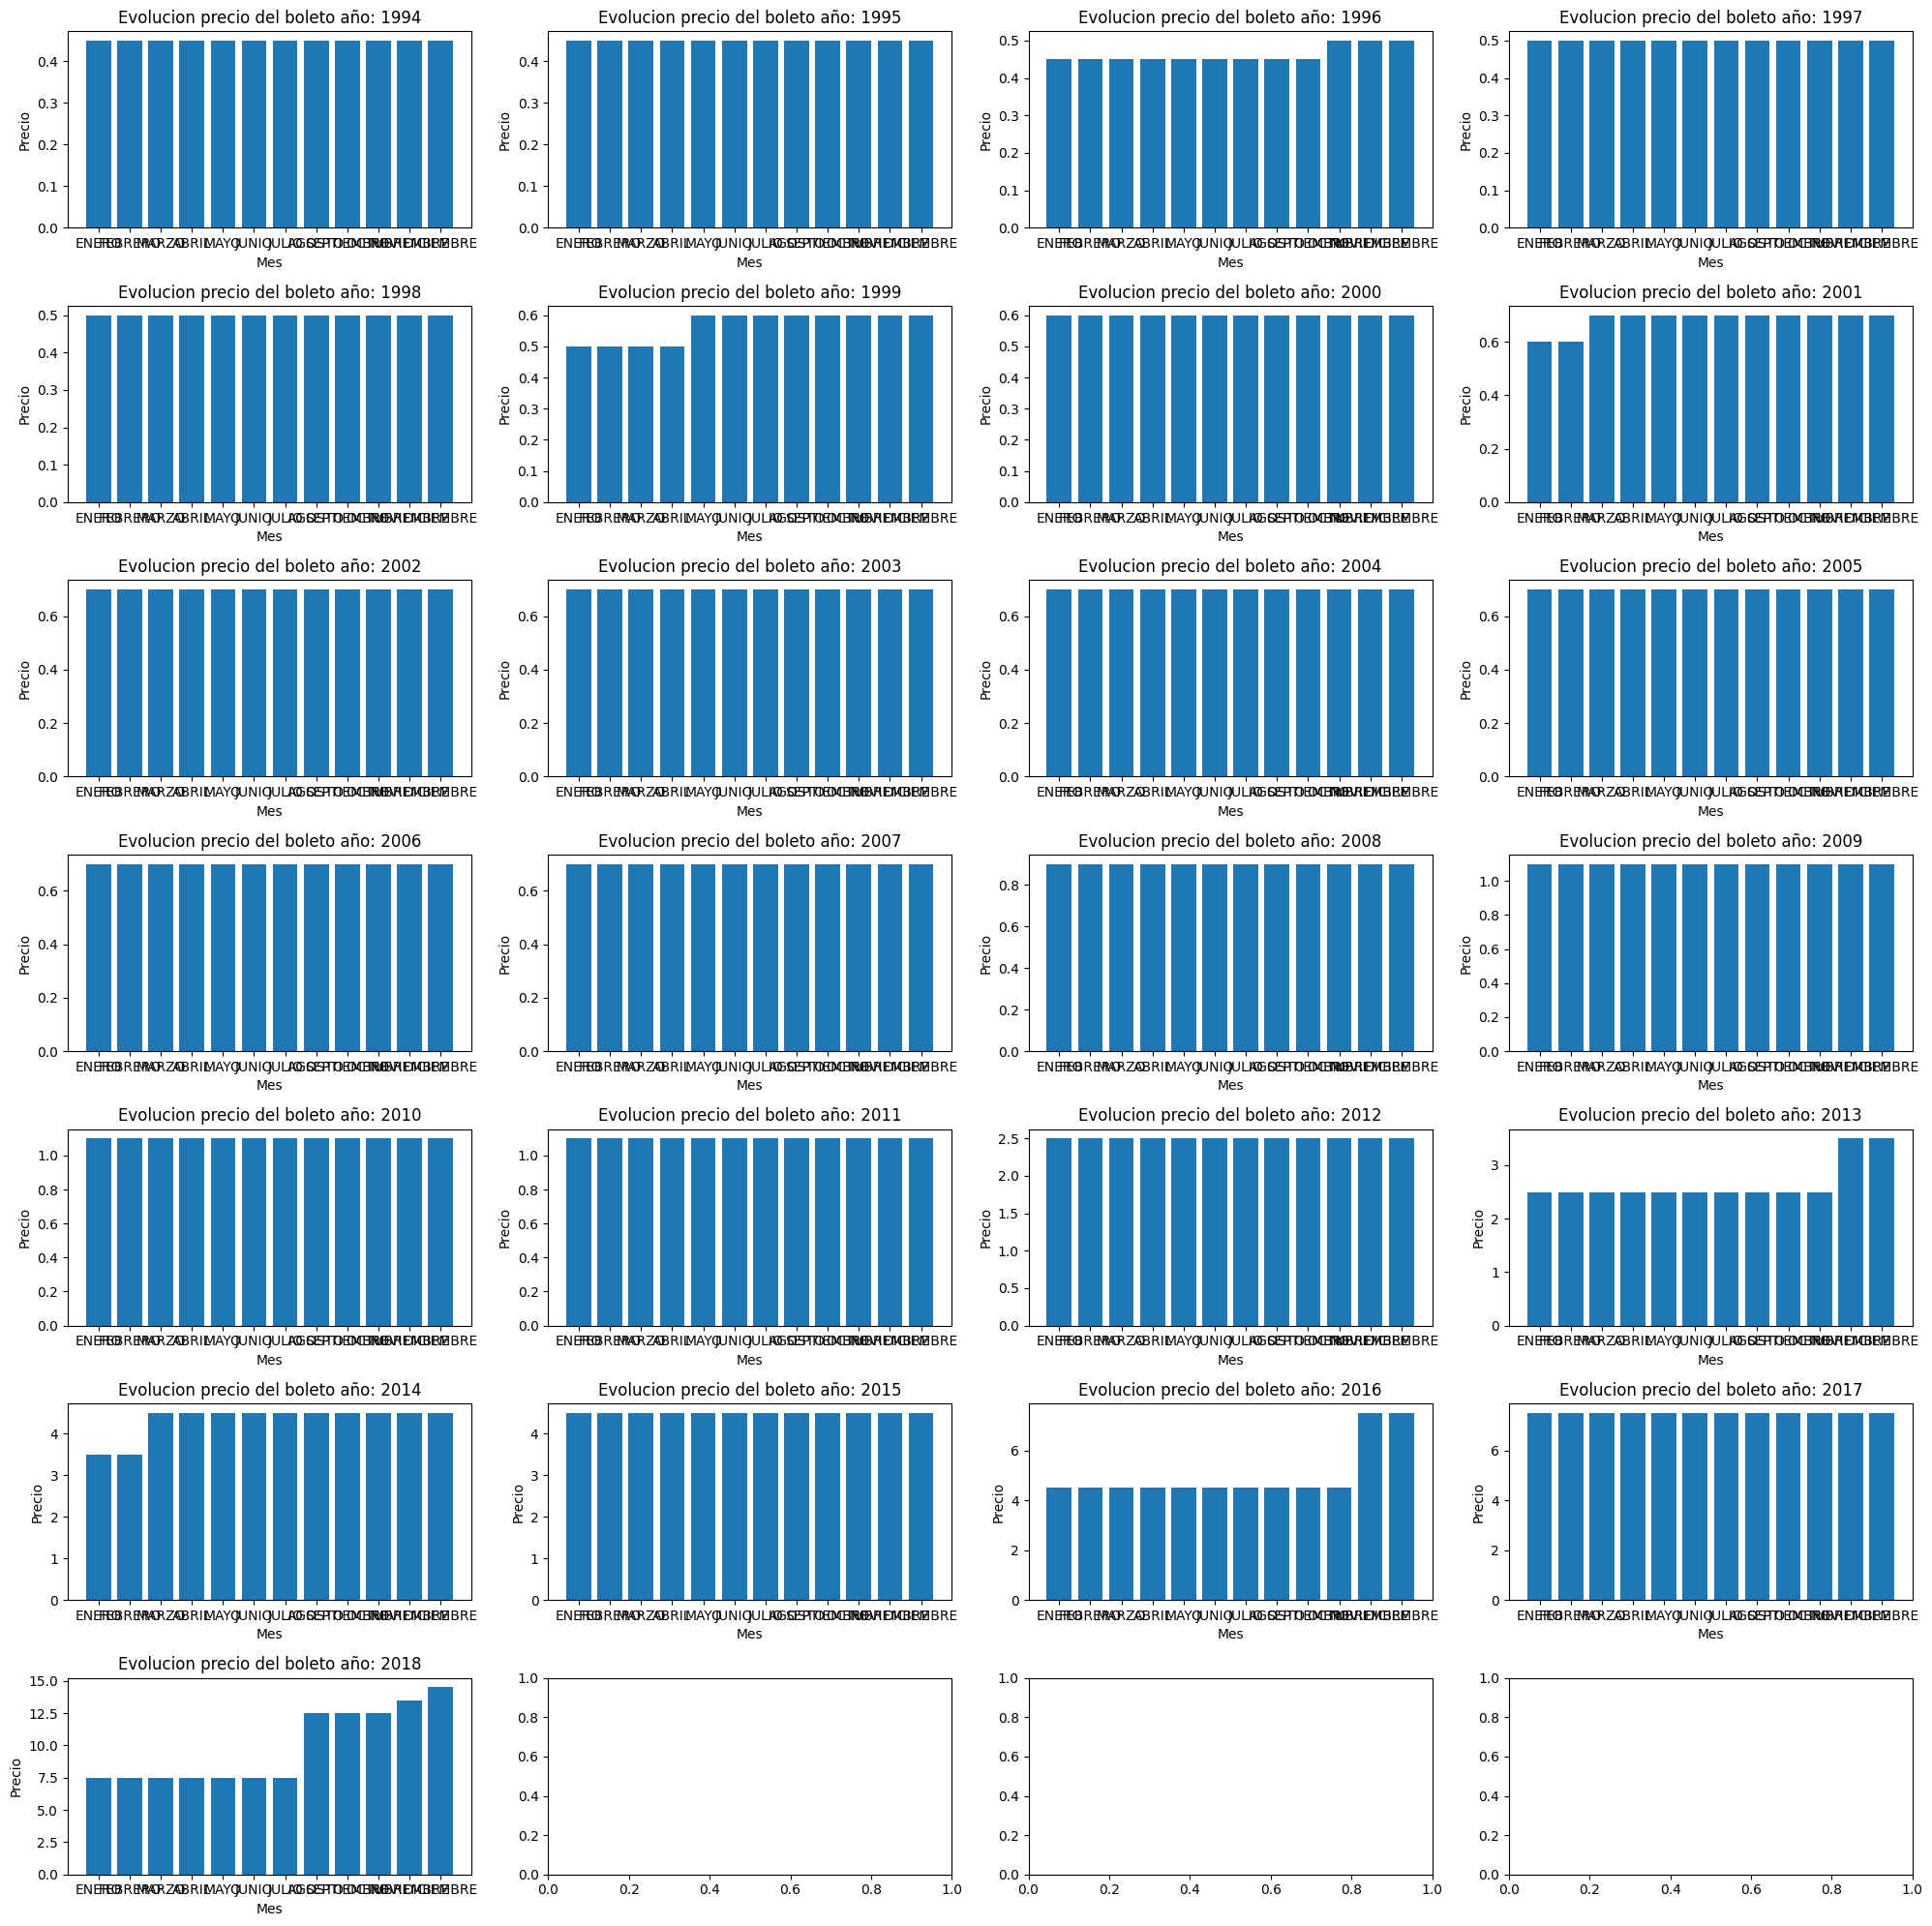

In [13]:
#ORGANIZO LOS DATOS PARA VISUALIZAR EN UNA TABLA Y GRAFICAR LA EVOLUCION DEL PRECIO DEL BOLETO POR AÑO. 

meses =['ENERO','FEBRERO', 'MARZO', 'ABRIL' , 'MAYO' ,'JUNIO', 'JULIO', 'AGOSTO' ,'SEPTIEMBRE', 'OCTUBRE' ,'NOVIEMBRE','DICIEMBRE']    

lineapass=df.pivot_table(index='año',columns='mes', values='precio',aggfunc='sum')
lineapass = lineapass[meses]
lineapass = lineapass.fillna(19)
print('Total de viajes por LINEA por AÑO.')
pd.set_option('display.width',1000)
print(lineapass)




# Datos de la tabla.
anios = [
    1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
    2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
    2016, 2017, 2018, 2019,
]
precios = [
    0.45, 0.45, 0.46, 0.50, 0.50, 0.58, 0.60, 0.68, 0.70, 0.70, 0.70,
    0.70, 0.70, 0.70, 0.90, 1.10, 1.10, 1.10, 2.50, 2.67, 4.33, 4.50,
    5.00, 7.50, 10.42, 18.50,
]

# Creo el gráfico de líneas.
plt.figure(figsize=(12, 6))  # Ajustar el tamaño del gráfico
plt.plot(anios, precios, marker='o', linestyle='-')

# Añado etiquetas y título.
plt.title('Evolución del Precio del Boleto de Subte (1994-2019)')
plt.xlabel('Año')
plt.ylabel('Precio del Boleto (Pesos Argentinos)')

# Ajusto los ticks del eje x para mostrar todos los años.
plt.xticks(anios, rotation=45)  # Rotar las etiquetas para mejor legibilidad

# Añado una cuadrícula para facilitar la lectura.
plt.grid(True, linestyle='--', alpha=0.6)

# Visualizo los gráficos.
plt.tight_layout()  # Ajustar el diseño para evitar cortes
plt.show()


fig,axs = plt.subplots(7,4, figsize=(20,20))

for i, year in enumerate(range (1994,2019)):
        ax = axs[i // 4, i%4]
        ax.bar(df.loc[df['año'] == year, 'mes'], df.loc[df['año'] == year, 'precio'])
        ax.set_title(f'Evolucion precio del boleto año: {year}')
        ax.set_xlabel('Mes')
        ax.set_ylabel('Precio')
print('Evolucion Precio Boleto Mensual')
plt.tight_layout()
plt.show()



- Por ultimo, con el siguiente bloque de código,  nos permitira visualizar la evolución mensual del precio del boleto de subte en Buenos Aires desde 2013 hasta 2021. 

- A continuación, se explica cada paso:

	1.	Estructura de datos: Cada lista (trece, catorce, etc.) representa un año, conteniendo tuplas con el nombre del mes y el precio correspondiente del boleto en ese mes.

	2.	Organización: Se agrupan todas las listas anuales en una sola (años) y se define el orden cronológico de los meses para estandarizar el eje x del gráfico.

	3.	Visualización:
- •	Se recorre cada año, extrayendo los precios mensuales y graficándolos.
- •	Cada línea en el grafico, representa la evolución del precio a lo largo de los 12 meses de un año específico.
- •	Se usa transparencia (alpha) y grosor de línea para mejorar la lectura.

	4.	Personalización del gráfico: Se agregan etiquetas, rotación de los meses, leyenda lateral para dar un diseño claro, permitiendonos comparar visualmente los aumentos del precio mes a mes y año a año.

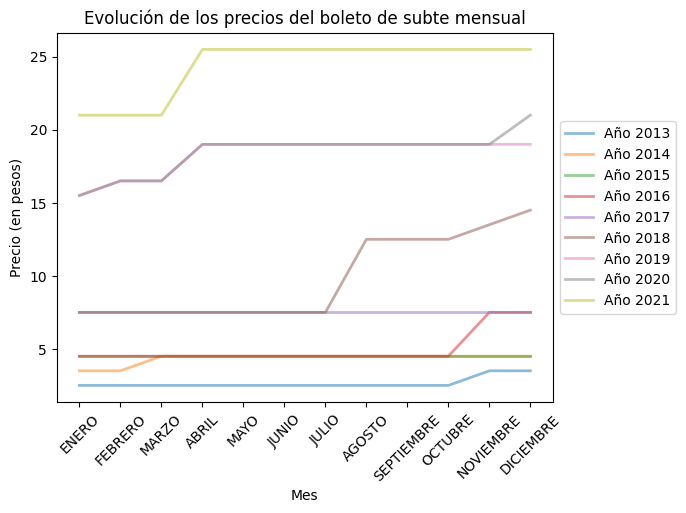

In [ ]:
#Estructura de los datos para el modelo.

trece = [('ENERO', 2.5), ('FEBRERO', 2.5), ('MARZO', 2.50), ('ABRIL', 2.50), ('MAYO', 2.50),  ('JUNIO', 2.50),  ('JULIO', 2.50),  ('AGOSTO', 2.50), ('SEPTIEMBRE', 2.50), ('OCTUBRE',  2.50), ('NOVIEMBRE', 3.50), ('DICIEMBRE', 3.50)]
catorce = [('ENERO', 3.5), ('FEBRERO', 3.5), ('MARZO', 4.50), ('ABRIL', 4.50), ('MAYO', 4.50),  ('JUNIO', 4.50),  ('JULIO', 4.50),  ('AGOSTO', 4.50), ('SEPTIEMBRE', 4.50), ('OCTUBRE',  4.50), ('NOVIEMBRE', 4.50), ('DICIEMBRE', 4.50)]
quince = [('ENERO', 4.5), ('FEBRERO', 4.5), ('MARZO', 4.50), ('ABRIL', 4.50), ('MAYO', 4.50),  ('JUNIO', 4.50),  ('JULIO', 4.50),  ('AGOSTO', 4.50), ('SEPTIEMBRE', 4.50), ('OCTUBRE',  4.50), ('NOVIEMBRE', 4.50), ('DICIEMBRE', 4.50)]
dieciseis = [('ENERO', 4.5), ('FEBRERO', 4.5), ('MARZO', 4.50), ('ABRIL', 4.50), ('MAYO', 4.50),  ('JUNIO', 4.50),  ('JULIO', 4.50),  ('AGOSTO', 4.50), ('SEPTIEMBRE', 4.50), ('OCTUBRE',  4.50), ('NOVIEMBRE', 7.50), ('DICIEMBRE', 7.50)]
diecisiete = [('ENERO', 7.50), ('FEBRERO', 7.50), ('MARZO', 7.50), ('ABRIL', 7.50), ('MAYO', 7.50),  ('JUNIO', 7.50),  ('JULIO', 7.50),  ('AGOSTO', 7.50), ('SEPTIEMBRE', 7.50), ('OCTUBRE',  7.50), ('NOVIEMBRE', 7.50), ('DICIEMBRE', 7.50)]
dieciocho = [('ENERO', 7.50), ('FEBRERO', 7.50), ('MARZO', 7.50), ('ABRIL', 7.50), ('MAYO', 7.50),  ('JUNIO', 7.50),  ('JULIO', 7.50),  ('AGOSTO', 12.50), ('SEPTIEMBRE', 12.50), ('OCTUBRE',  12.50), ('NOVIEMBRE', 13.50), ('DICIEMBRE', 14.50)]
diecinueve = [('ENERO', 15.5), ('FEBRERO', 16.5), ('MARZO', 16.50), ('ABRIL', 19.0), ('MAYO', 19.0),  ('JUNIO', 19.0),  ('JULIO', 19.0),  ('AGOSTO', 19.0), ('SEPTIEMBRE', 19.0), ('OCTUBRE',  19.0), ('NOVIEMBRE', 19.0), ('DICIEMBRE', 19.0)]
veinte = [('ENERO', 15.5), ('FEBRERO', 16.5), ('MARZO', 16.50), ('ABRIL', 19.0), ('MAYO', 19.0),  ('JUNIO', 19.0),  ('JULIO', 19.0),  ('AGOSTO', 19.0), ('SEPTIEMBRE', 19.0), ('OCTUBRE',  19.0), ('NOVIEMBRE', 19.0), ('DICIEMBRE', 21)]
veintiuno = [('ENERO', 21), ('FEBRERO', 21), ('MARZO', 21), ('ABRIL', 25.50), ('MAYO', 25.50),  ('JUNIO', 25.50),  ('JULIO', 25.50),  ('AGOSTO', 25.50), ('SEPTIEMBRE', 25.50), ('OCTUBRE',  25.50), ('NOVIEMBRE', 25.50), ('DICIEMBRE', 25.50)]




import matplotlib.pyplot as plt

# Tuplas con los precios del boleto de subte mensual
años = [trece, catorce, quince, dieciseis, diecisiete, dieciocho, diecinueve, veinte, veintiuno]

meses = ['ENERO', 'FEBRERO', 'MARZO', 'ABRIL', 'MAYO', 'JUNIO', 'JULIO', 'AGOSTO', 'SEPTIEMBRE', 'OCTUBRE', 'NOVIEMBRE', 'DICIEMBRE']

for i, año in enumerate(años):
    precios = [t[1] for t in año]
    plt.plot(meses, precios, label=f'Año {2013 + i}', alpha= 0.5, linewidth = 2)


plt.title('Evolución de los precios del boleto de subte mensual')
plt.xlabel('Mes')
plt.ylabel('Precio (en pesos)')
plt.xticks(rotation=45)  # Rotar las etiquetas de los meses para mejorar la legibilidad
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

**ALGUNAS CONCLUSIONES**

**Análisis del gráfico de evolución mensual del precio del boleto de subte (2013–2021):**


- Análisis de aumentos del precio del boleto:

	1.	Estabilidad prolongada:
- •	Entre 2013 y mediados de 2016, el precio del boleto se mantuvo relativamente estable, con un valor de $4.50 durante varios meses/años consecutivos.

	2.	Primer salto fuerte:
- •	A finales de 2016, el boleto pasó de $4.50 a $7.50 (noviembre). Este valor se mantuvo constante durante todo 2017 y principios de 2018.

	3.	Incremento progresivo:
- •	A partir de agosto de 2018, se observa una serie de aumentos mensuales:
- •	Agosto: $12.50
- •	Noviembre: $13.50
- •	Diciembre: $14.50
    
	4.	Mayor pico de aumento:
- •	2019 marca un aumento abrupto de enero ($15.5) a abril ($19), manteniéndose ese valor el resto del año.
	5.	Segunda gran suba:
- •	En abril de 2021, se registra otro fuerte aumento: de $21 a $25.50, que se mantiene hasta fin de año.

⸻

- En resumen:
- •	El mayor salto en un solo mes ocurrió entre marzo y abril de 2021: +$4.50
- •	El año con mayor variación intermensual fue 2018, con aumentos casi trimestrales.
- •	La tendencia general es aceleradamente ascendente a partir de 2016, especialmente tras 2018.

**Porcentaje de aumento anual del precio del boleto:**

- Año	% Aumento Anual
- 2013	40.00%
- 2014	28.57%
- 2015	0.00%
- 2016	66.67%
- 2017	0.00%
- 2018	93.33%
- 2019	22.58%
- 2020	35.48%
- 2021	21.43%

2018 fue el año con mayor incremento anual acumulado.

**Variación mensual de 2018 (%):**

- [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 66.67, 0.0, 0.0, 8.0, 7.41]

Esto refleja aumentos significativos en agosto, noviembre y diciembre. ￼

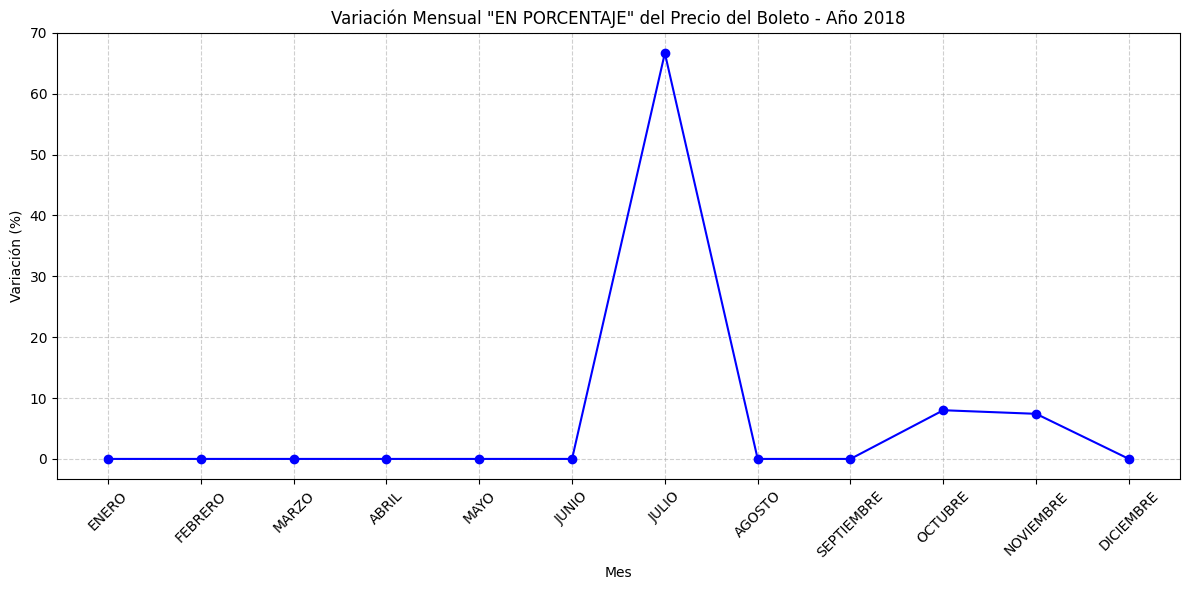

In [16]:
import matplotlib.pyplot as plt

# Variación mensual 2018
meses = ['ENERO', 'FEBRERO', 'MARZO', 'ABRIL', 'MAYO', 'JUNIO', 'JULIO',
         'AGOSTO', 'SEPTIEMBRE', 'OCTUBRE', 'NOVIEMBRE', 'DICIEMBRE']
variacion_mensual_2018 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 66.67, 0.0, 0.0, 8.0, 7.41, 0.0]

# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(meses, variacion_mensual_2018, marker='o', linestyle='-', color='blue')
plt.title('Variación Mensual "EN PORCENTAJE" del Precio del Boleto - Año 2018')
plt.xlabel('Mes')
plt.ylabel('Variación (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**ESTOS DATOS ME VAN A SERVIR PARA SUMARLOS A LAS DEMAS DATAFRAMES PARA PODER ANALIZAR EL IMPACTO DE LA SUBA DEL PRECIO.**